## <수능특강 - Binary Classification - Support Vector Machine - 수능특강 중심>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm

# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)

#### 수능특강 독서 P. 276 5번 문제 <보기> <표>

In [3]:
df=pd.DataFrame({
    "N": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "x": [200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100],
    "y": [40, 40, 20, 20, 25, 40, 50, 50, 30, 30],
    "Q": [0, 0, 1, 0, 0, 1, 1, 1, 1, 1]
})

print(df)

    N     x   y  Q
0   1   200  40  0
1   2   300  40  0
2   3   400  20  1
3   4   500  20  0
4   5   600  25  0
5   6   700  40  1
6   7   800  50  1
7   8   900  50  1
8   9  1000  30  1
9  10  1100  30  1


In [4]:
test=pd.DataFrame({
    "N": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    "x": [200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 700],
    "y": [40, 40, 20, 20, 25, 40, 50, 50, 30, 30, 60],
    "Q": [0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1]
})

print(test)

     N     x   y  Q
0    1   200  40  0
1    2   300  40  0
2    3   400  20  1
3    4   500  20  0
4    5   600  25  0
5    6   700  40  1
6    7   800  50  1
7    8   900  50  1
8    9  1000  30  1
9   10  1100  30  1
10  11   700  60  1


#### 수능특강 독서 P. 276 5번 문제 <보기> <그림>, 2번 선지 관련

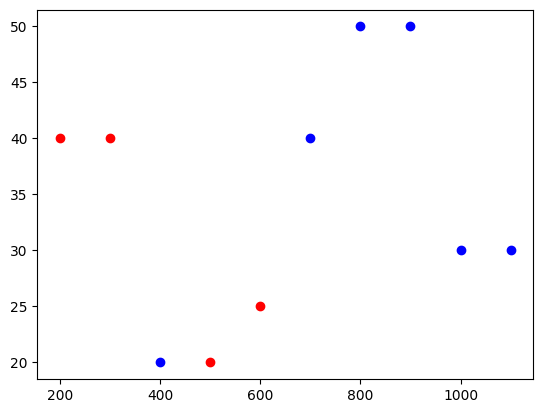

In [5]:
plt.scatter(df[df["Q"]==0]["x"], df[df["Q"]==0]["y"], color='red')
plt.scatter(df[df["Q"]==1]["x"], df[df["Q"]==1]["y"], color='blue')

plt.show()

In [6]:
df.drop(index=2, inplace=True)

print(df)

    N     x   y  Q
0   1   200  40  0
1   2   300  40  0
3   4   500  20  0
4   5   600  25  0
5   6   700  40  1
6   7   800  50  1
7   8   900  50  1
8   9  1000  30  1
9  10  1100  30  1


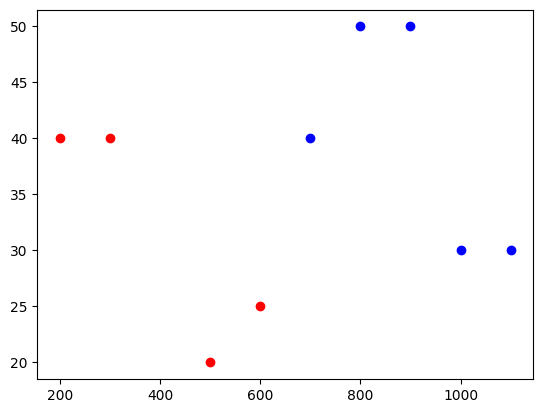

In [7]:
plt.scatter(df[df["Q"]==0]["x"], df[df["Q"]==0]["y"], color='red')
plt.scatter(df[df["Q"]==1]["x"], df[df["Q"]==1]["y"], color='blue')

plt.show()

#### SVM 모델 구축

In [8]:
features=df[["x", "y"]]

print(features)

      x   y
0   200  40
1   300  40
3   500  20
4   600  25
5   700  40
6   800  50
7   900  50
8  1000  30
9  1100  30


In [9]:
labels=df["Q"]

print(labels)

0    0
1    0
3    0
4    0
5    1
6    1
7    1
8    1
9    1
Name: Q, dtype: int64


In [10]:
clf=svm.SVC(kernel='linear')
clf.fit(features, labels)

SVC(kernel='linear')

#### 수능특강 독서 P. 276 5번 문제 3번 선지 관련

In [11]:
print(clf.support_vectors_)

[[600.  25.]
 [700.  40.]]


#### 수능특강 독서 P. 276 5번 문제 4번 선지 관련

In [12]:
test_features=test[["x", "y"]]

print(test_features)

       x   y
0    200  40
1    300  40
2    400  20
3    500  20
4    600  25
5    700  40
6    800  50
7    900  50
8   1000  30
9   1100  30
10   700  60


In [13]:
test_labels=test["Q"]

print(test_labels)

0     0
1     0
2     1
3     0
4     0
5     1
6     1
7     1
8     1
9     1
10    1
Name: Q, dtype: int64


In [14]:
predictions=clf.predict(test_features)

print(predictions)

[0 0 0 0 0 1 1 1 1 1 1]


#### 수능특강 독서 P. 276 5번 문제 1번 선지 관련

In [15]:
print(clf.coef_[0], clf.intercept_)

[0.0195599  0.00293399] [-12.80929095]


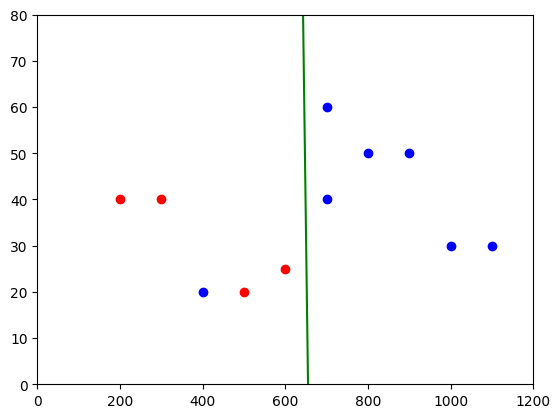

In [16]:
xx=np.linspace(0, 1200)
yy=-clf.coef_[0][0]/clf.coef_[0][1] * xx - clf.intercept_[0]/clf.coef_[0][1]

plt.scatter(test[test["Q"]==0]["x"], test[test["Q"]==0]["y"], color='red')
plt.scatter(test[test["Q"]==1]["x"], test[test["Q"]==1]["y"], color='blue')
plt.plot(xx, yy, color='green')
plt.xlim(0, 1200)
plt.ylim(0, 80)

plt.show()